## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.


In [1]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga e Datetime
df = pd.read_excel("base_rh.xlsx")
df['Data_Admissao'] = pd.to_datetime(df['Data_Admissao'])
df['Ano_Admissao'] = df['Data_Admissao'].dt.year

# Contagem por Depto e Cargo
contagem_depto_cargo = df.groupby(["Departamento", "Cargo"]).size()
print(contagem_depto_cargo)

# Filtro de Admissões Recentes (2020-2024)
admissoes_ano = df.groupby("Ano_Admissao").size().reset_index(name='Qtd')
recentes = admissoes_ano.query("2020 <= Ano_Admissao <= 2024")

C:\Users\Bete\AppData\Local\Temp\ipykernel_8164\3181076679.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Data_Admissao'] = pd.to_datetime(df['Data_Admissao'])


Departamento  Cargo      
Financeiro    Analista       40
              Assistente     30
              Coordenador    37
              Gerente        44
              Técnico        38
Logística     Analista       29
              Assistente     38
              Coordenador    38
              Gerente        33
              Técnico        18
Produção      Analista       22
              Assistente     41
              Coordenador    40
              Gerente        43
              Técnico        36
RH            Analista       32
              Assistente     35
              Coordenador    44
              Gerente        30
              Técnico        25
TI            Analista       31
              Assistente     25
              Coordenador    28
              Gerente        31
              Técnico        32
Vendas        Analista       24
              Assistente     30
              Coordenador    38
              Gerente        40
              Técnico        28
dtype: int64


In [7]:
# Tabela de Metas e Merge
metas = pd.DataFrame({
    'Departamento' : ['Produção', 'RH', 'Financeiro', 'Vendas'],
    'Meta_Headcount' : [500, 20, 15, 50]
})

total_depto = df.groupby("Departamento").size().reset_index(name='Real')
df_metas = pd.merge(total_depto, metas, on="Departamento", how="left")
df_metas['Atingiu_Meta'] = df_metas['Real'] <= df_metas['Meta_Headcount']

# Pivot Table do Salário Médio
pivot_salario = df.pivot_table(index="Departamento", columns="Genero", values="Salario", aggfunc="mean")
pivot_salario['Diff_F_M'] = pivot_salario['F'] - pivot_salario['M']

<function matplotlib.pyplot.show(close=None, block=None)>

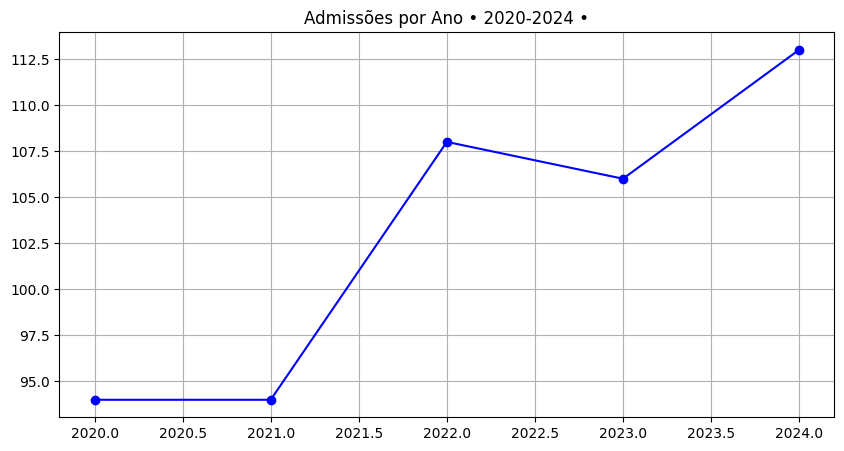

In [9]:
# Admissões (Gráfico de linha)
plt.figure(figsize=(10,5))
plt.plot(recentes['Ano_Admissao'], recentes['Qtd'], marker="o", color="blue")
plt.title("Admissões por Ano • 2020-2024 •")
plt.grid(True)
plt.show

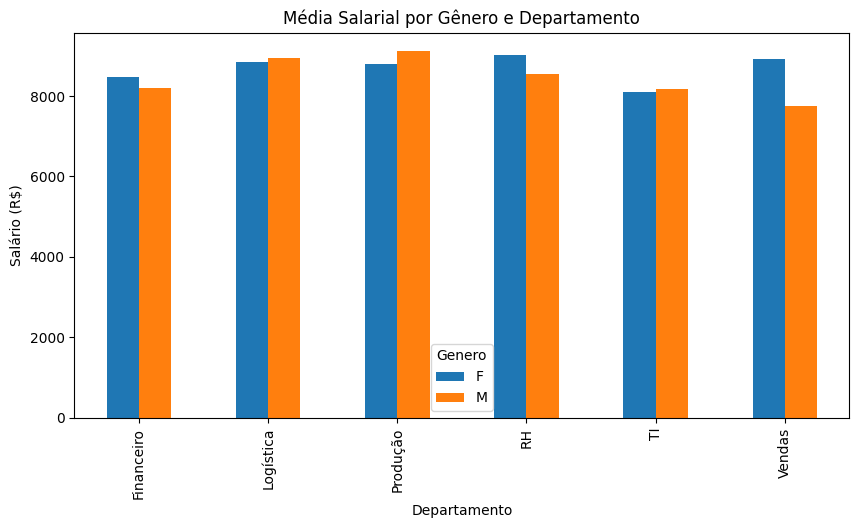

In [10]:
# Salário por gênero (Gráfico de barras)
pivot_salario[['F','M']].plot(kind="bar", figsize=(10,5))
plt.title("Média Salarial por Gênero e Departamento")
plt.ylabel("Salário (R$)")
plt.show()

Git Log:
c018be8 (HEAD -> master, origin/master, origin/HEAD) semana 05 - dia 02: groupby, merge, pivot_table, gráficos
ed3bda1 Enviando pasta semana_05
ad5b2df Merge branch 'master' of https://github.com/cfneves/turma-visualizacao-de-dados